In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [37]:
np.random.seed(42)

n = 1000

age = np.random.randint(4, 9, n)

gender = np.random.choice(
    ["Female", "Male"],
    size=n
)

sugar_intake = np.random.choice(
    ["Low", "Medium", "High"],
    size=n,
    p=[0.30, 0.45, 0.25]
)

previous_cavities = np.random.choice(
    ["No", "Yes"],
    size=n,
    p=[0.65, 0.35]
)

engagement_score = np.random.randint(10, 101, n)

weekly_app_usage = np.clip(
    np.round(engagement_score / 7 + np.random.normal(0, 2, n)),
    0,
    21
).astype(int)

missions_completed = np.clip(
    np.round(weekly_app_usage * 0.75 + np.random.normal(0, 2, n)),
    0,
    14
).astype(int)

reminder_response_rate = np.clip(
    engagement_score + np.random.normal(0, 15, n),
    0,
    100
).round(1)

daily_brushing_frequency = np.clip(
    0.5
    + missions_completed * 0.1
    + reminder_response_rate * 0.004
    + np.random.normal(0, 0.25, n),
    0,
    2.5
).round(2)

average_brushing_duration = np.clip(
    0.7
    + missions_completed * 0.08
    + reminder_response_rate * 0.003
    + np.random.normal(0, 0.3, n),
    0.5,
    3.0
).round(2)

reward_points = np.clip(
    missions_completed * np.random.randint(15, 31, n)
    + np.random.normal(20, 30, n),
    0,
    500
).astype(int)

badges_unlocked = np.clip(
    np.round(missions_completed / 3 + np.random.normal(0, 1, n)),
    0,
    10
).astype(int)

parent_dashboard_visits = np.clip(
    np.round(
        1
        + missions_completed * 0.15
        + (previous_cavities == "Yes") * 1.5
        + np.random.normal(0, 1.5, n)
    ),
    0,
    14
).astype(int)

story_levels_completed = np.clip(
    np.round(missions_completed / 2.5 + np.random.normal(0, 1, n)),
    0,
    8
).astype(int)

In [38]:
risk_score = (
    35
    - 9 * daily_brushing_frequency
    - 5 * average_brushing_duration
    - 0.10 * reminder_response_rate
    - 0.55 * missions_completed
    - 0.05 * engagement_score
    - 0.25 * parent_dashboard_visits
    + 5 * (sugar_intake == "High")
    + 2 * (sugar_intake == "Medium")
    + 5 * (previous_cavities == "Yes")
    + np.random.normal(0, 6, n)
)

low_cutoff = np.quantile(risk_score, 0.34)
high_cutoff = np.quantile(risk_score, 0.67)

risk_level = np.where(
    risk_score <= low_cutoff,
    "Low",
    np.where(
        risk_score <= high_cutoff,
        "Medium",
        "High"
    )
)

In [39]:
data = pd.DataFrame({
    "Child_ID": np.arange(1, n + 1),
    "Age": age,
    "Gender": gender,
    "Daily_Brushing_Frequency": daily_brushing_frequency,
    "Average_Brushing_Duration": average_brushing_duration,
    "Reminder_Response_Rate": reminder_response_rate,
    "Weekly_App_Usage": weekly_app_usage,
    "Missions_Completed": missions_completed,
    "Reward_Points": reward_points,
    "Badges_Unlocked": badges_unlocked,
    "Parent_Dashboard_Visits": parent_dashboard_visits,
    "Story_Levels_Completed": story_levels_completed,
    "Sugar_Intake": sugar_intake,
    "Previous_Cavities": previous_cavities,
    "Engagement_Score": engagement_score,
    "Risk_Level": risk_level
})

data.head()

,Child_ID,Age,Gender,Daily_Brushing_Frequency,Average_Brushing_Duration,Reminder_Response_Rate,Weekly_App_Usage,Missions_Completed,Reward_Points,Badges_Unlocked,Parent_Dashboard_Visits,Story_Levels_Completed,Sugar_Intake,Previous_Cavities,Engagement_Score,Risk_Level
0,1,7,Male,1.58,1.42,91.4,7,7,205,4,3,3,Low,No,66,Low
1,2,8,Male,1.57,1.90,80.0,8,6,210,3,1,1,Low,No,58,Low
2,3,6,Male,1.13,1.32,79.1,8,2,36,2,0,0,Medium,No,54,Medium
3,4,8,Male,2.04,1.99,77.3,12,8,196,2,3,4,Medium,No,91,Low
4,5,8,Male,1.06,1.29,82.4,7,3,66,1,0,0,Low,Yes,75,High


In [40]:
print(data.shape)
print(data["Risk_Level"].value_counts())
print(data.isnull().sum())

(1000, 16)
Risk_Level
Low       340
Medium    330
High      330
Name: count, dtype: int64
Child_ID                     0
Age                          0
Gender                       0
Daily_Brushing_Frequency     0
Average_Brushing_Duration    0
Reminder_Response_Rate       0
Weekly_App_Usage             0
Missions_Completed           0
Reward_Points                0
Badges_Unlocked              0
Parent_Dashboard_Visits      0
Story_Levels_Completed       0
Sugar_Intake                 0
Previous_Cavities            0
Engagement_Score             0
Risk_Level                   0
dtype: int64


In [41]:
data.to_csv(
    "synthetic_tooth_kingdom_data.csv",
    index=False
)

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Child_ID                   1000 non-null   int64  
 1   Age                        1000 non-null   int64  
 2   Gender                     1000 non-null   object 
 3   Daily_Brushing_Frequency   1000 non-null   float64
 4   Average_Brushing_Duration  1000 non-null   float64
 5   Reminder_Response_Rate     1000 non-null   float64
 6   Weekly_App_Usage           1000 non-null   int64  
 7   Missions_Completed         1000 non-null   int64  
 8   Reward_Points              1000 non-null   int64  
 9   Badges_Unlocked            1000 non-null   int64  
 10  Parent_Dashboard_Visits    1000 non-null   int64  
 11  Story_Levels_Completed     1000 non-null   int64  
 12  Sugar_Intake               1000 non-null   object 
 13  Previous_Cavities          1000 non-null   object

In [43]:
data.describe(include="all")

,Child_ID,Age,Gender,Daily_Brushing_Frequency,Average_Brushing_Duration,Reminder_Response_Rate,Weekly_App_Usage,Missions_Completed,Reward_Points,Badges_Unlocked,Parent_Dashboard_Visits,Story_Levels_Completed,Sugar_Intake,Previous_Cavities,Engagement_Score,Risk_Level
count,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000.00000,1000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2,NaN,3
top,NaN,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,No,NaN,Low
freq,NaN,NaN,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456,653,NaN,340
mean,500.500000,6.004000,NaN,1.320700,1.351170,55.620500,7.919000,6.016000,156.202000,2.043000,2.522000,2.479000,NaN,NaN,55.85200,NaN
std,288.819436,1.433192,NaN,0.497189,0.455615,28.178966,4.161461,3.552233,91.117603,1.488411,1.661408,1.681781,NaN,NaN,26.20956,NaN
min,1.000000,4.000000,NaN,0.020000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,10.00000,NaN
25%,250.750000,5.000000,NaN,0.940000,0.997500,33.300000,5.000000,3.000000,87.750000,1.000000,1.000000,1.000000,NaN,NaN,32.00000,NaN
50%,500.500000,6.000000,NaN,1.325000,1.340000,55.900000,8.000000,6.000000,149.000000,2.000000,2.000000,2.000000,NaN,NaN,57.00000,NaN
75%,750.250000,7.000000,NaN,1.682500,1.682500,78.800000,11.000000,9.000000,215.250000,3.000000,4.000000,4.000000,NaN,NaN,78.00000,NaN


In [44]:
print("Duplicate rows:", data.duplicated().sum())
print("\nMissing values:\n")
print(data.isnull().sum())

Duplicate rows: 0

Missing values:

Child_ID                     0
Age                          0
Gender                       0
Daily_Brushing_Frequency     0
Average_Brushing_Duration    0
Reminder_Response_Rate       0
Weekly_App_Usage             0
Missions_Completed           0
Reward_Points                0
Badges_Unlocked              0
Parent_Dashboard_Visits      0
Story_Levels_Completed       0
Sugar_Intake                 0
Previous_Cavities            0
Engagement_Score             0
Risk_Level                   0
dtype: int64


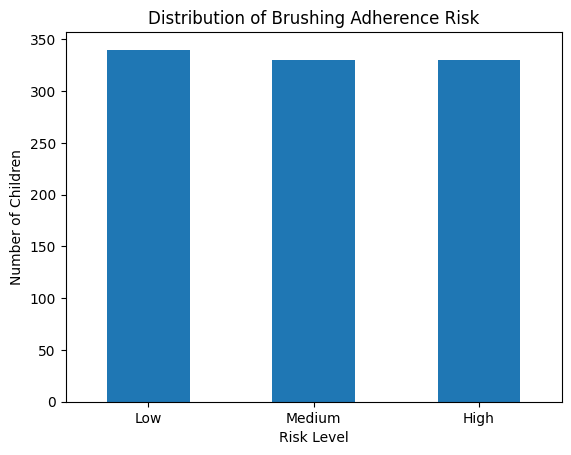

In [45]:
data["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Distribution of Brushing Adherence Risk")
plt.xlabel("Risk Level")
plt.ylabel("Number of Children")
plt.xticks(rotation=0)
plt.show()

In [46]:
X = data.drop(columns=["Child_ID", "Risk_Level"])
y = data["Risk_Level"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (1000, 14)
Target shape: (1000,)


In [47]:
categorical_features = [
    "Gender",
    "Sugar_Intake",
    "Previous_Cavities"
]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Gender', 'Sugar_Intake', 'Previous_Cavities']
Numerical features: ['Age', 'Daily_Brushing_Frequency', 'Average_Brushing_Duration', 'Reminder_Response_Rate', 'Weekly_App_Usage', 'Missions_Completed', 'Reward_Points', 'Badges_Unlocked', 'Parent_Dashboard_Visits', 'Story_Levels_Completed', 'Engagement_Score']


In [48]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 800
Testing records: 200


In [50]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

In [51]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)

In [52]:
model_pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [53]:
y_pred = model_pipeline.predict(X_test)

print(y_pred[:10])

['Low' 'Low' 'High' 'Low' 'Medium' 'High' 'Low' 'High' 'Low' 'Low']


In [54]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.3f}")

Model accuracy: 0.795


In [55]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

        High       0.83      0.86      0.84        66
         Low       0.89      0.81      0.85        68
      Medium       0.68      0.71      0.70        66

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.80       200
weighted avg       0.80      0.80      0.80       200



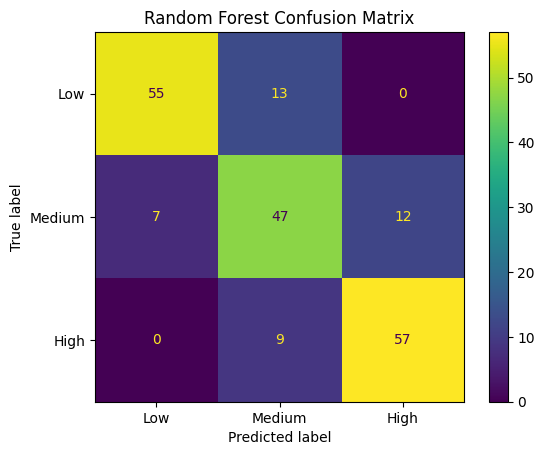

In [56]:
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display.plot(values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.show()

In [57]:
display.figure_.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [58]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    model_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro"
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Daily_Brushing_Frequency,0.094809
4,Reminder_Response_Rate,0.025368
6,Missions_Completed,0.018058
12,Previous_Cavities,0.017504
11,Sugar_Intake,0.009822
3,Average_Brushing_Duration,0.009535
5,Weekly_App_Usage,0.004532
1,Gender,0.003811
10,Story_Levels_Completed,0.002912
13,Engagement_Score,0.000895


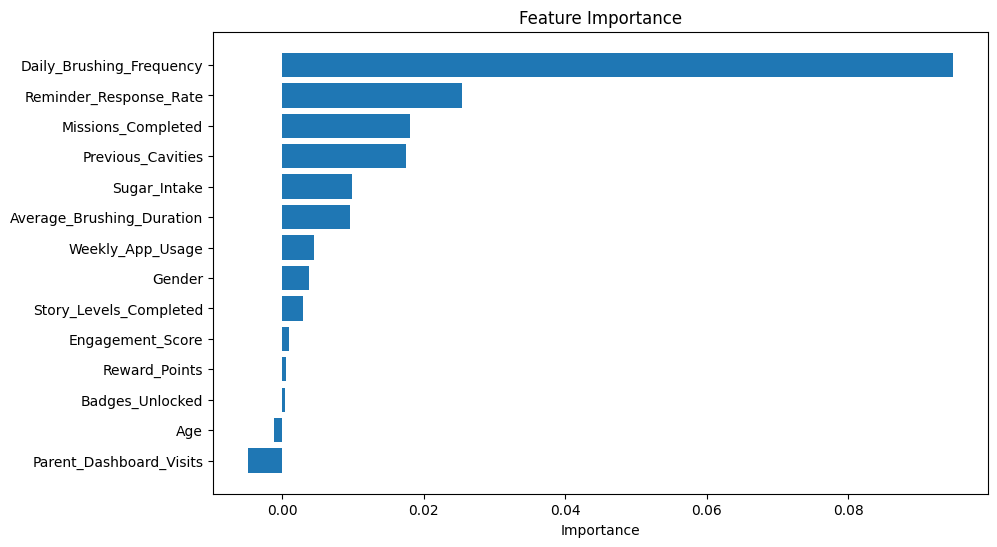

In [59]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [60]:
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

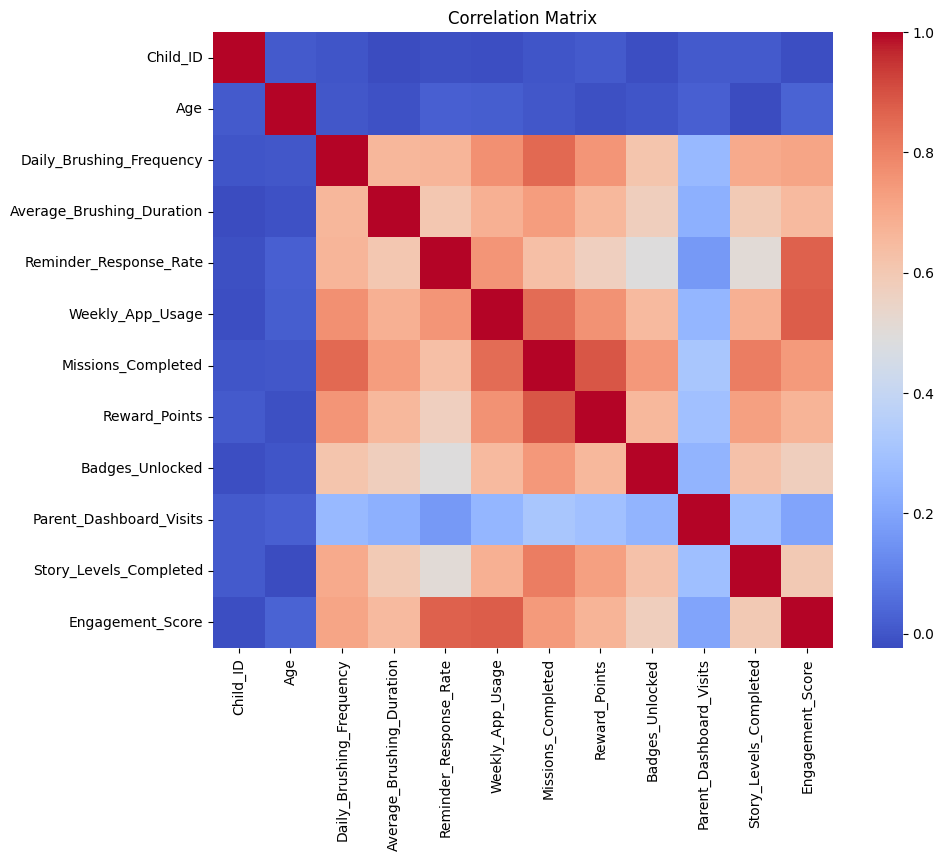

In [61]:
import seaborn as sns

numeric = data.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [62]:
import joblib

joblib.dump(
    model_pipeline,
    "Tooth_Kingdom_RF.joblib"
)

['Tooth_Kingdom_RF.joblib']

In [63]:
kingdom_level = np.clip(
    np.round(
        1
        + story_levels_completed
        + missions_completed * 0.2
        + badges_unlocked * 0.4
        + np.random.normal(0, 1, n)
    ),
    1,
    20
).astype(int)

weekly_challenge_completed = np.where(
    (
        (missions_completed >= 8) &
        (daily_brushing_frequency >= 1.5)
    ),
    "Yes",
    "No"
)

In [64]:
data["Kingdom_Level"] = kingdom_level

data["Weekly_Challenge_Completed"] = weekly_challenge_completed

data.head()

,Child_ID,Age,Gender,Daily_Brushing_Frequency,Average_Brushing_Duration,Reminder_Response_Rate,Weekly_App_Usage,Missions_Completed,Reward_Points,Badges_Unlocked,Parent_Dashboard_Visits,Story_Levels_Completed,Sugar_Intake,Previous_Cavities,Engagement_Score,Risk_Level,Kingdom_Level,Weekly_Challenge_Completed
0,1,7,Male,1.58,1.42,91.4,7,7,205,4,3,3,Low,No,66,Low,6,No
1,2,8,Male,1.57,1.90,80.0,8,6,210,3,1,1,Low,No,58,Low,7,No
2,3,6,Male,1.13,1.32,79.1,8,2,36,2,0,0,Medium,No,54,Medium,2,No
3,4,8,Male,2.04,1.99,77.3,12,8,196,2,3,4,Medium,No,91,Low,7,Yes
4,5,8,Male,1.06,1.29,82.4,7,3,66,1,0,0,Low,Yes,75,High,2,No


In [65]:
X = data.drop(columns=["Child_ID", "Risk_Level"])
y = data["Risk_Level"]

In [66]:
categorical_features = [
    "Gender",
    "Sugar_Intake",
    "Previous_Cavities",
    "Weekly_Challenge_Completed"
]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

In [67]:
data.to_csv(
    "synthetic_tooth_kingdom_data.csv",
    index=False
)

print("Final dataset saved.")

Final dataset saved.


In [68]:
import joblib

joblib.dump(
    model_pipeline,
    "Tooth_Kingdom_RF.joblib"
)

print("Final model saved.")

Final model saved.


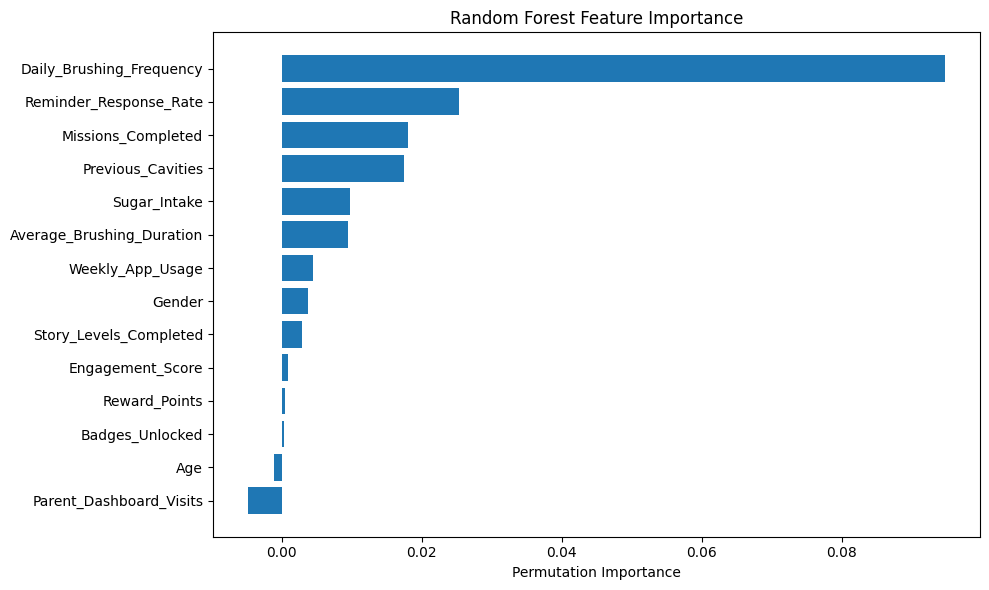

In [69]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Permutation Importance")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

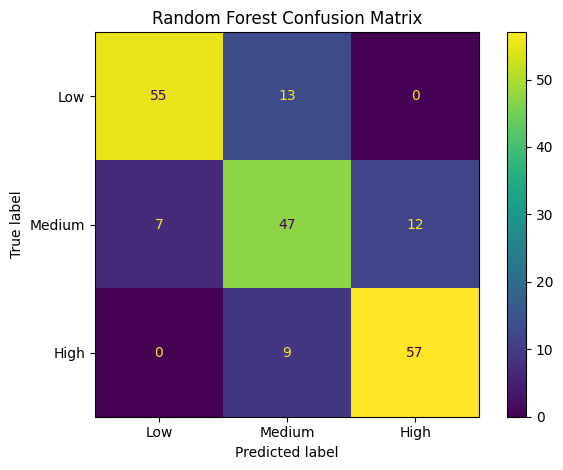

In [70]:
labels = ["Low", "Medium", "High"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

display.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()